In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../dataset/city_day.csv")

### Basic Checking/ Initial Inspection

In [3]:
# checking first few rows
df.head(5)

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
# dataset shape
df.shape

(29531, 16)

In [5]:
# dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 4.3 MB


In [6]:
# descriptive stats
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


### Handling Missing Values

In [7]:
# checking number of missing values in each column
df.isna().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [8]:
# dropping rows with missing AQI (ie our target variable)
df=df.dropna(subset=['AQI'])
df.isna().sum()

City              0
Date              0
PM2.5           678
PM10           7086
NO              387
NO2             391
NOx            1857
NH3            6536
CO              445
SO2             605
O3              807
Benzene        3535
Toluene        5826
Xylene        15372
AQI               0
AQI_Bucket        0
dtype: int64

In [9]:
# replacing missing pollutnt values with median
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
for col in pollutants:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df.isna().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

### Data Type Correction

In [10]:
# check data types
df.dtypes

City              str
Date              str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

In [11]:
# fix date datatype to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dtypes

City                     str
Date          datetime64[us]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket               str
dtype: object

In [12]:
# convert AQI_Bucket to categorical
df['AQI_Bucket'] = df['AQI_Bucket'].astype('category')
df.dtypes

City                     str
Date          datetime64[us]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket          category
dtype: object

### Standardization

In [13]:
# check unique City names
df['City'].unique()

<ArrowStringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

### Removing duplicates

In [14]:
# count duplicates
df.duplicated().sum()

np.int64(0)

### Consistency Check

In [15]:
# numeric values >=0 and AQI Cap 500
numeric_cols = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene','AQI']
for col in numeric_cols:
    if col in df.columns:
        # Count negatives
        neg_count = (df[col] < 0).sum()
        print(f"{col}: {neg_count} negative values")
        # Replace negative values with NaN
        df[col] = df[col].apply(lambda x: np.nan if x < 0 else x)
df['AQI'] = df['AQI'].clip(lower=0, upper=500)

PM2.5: 0 negative values
PM10: 0 negative values
NO: 0 negative values
NO2: 0 negative values
NOx: 0 negative values
NH3: 0 negative values
CO: 0 negative values
SO2: 0 negative values
O3: 0 negative values
Benzene: 0 negative values
Toluene: 0 negative values
Xylene: 0 negative values
AQI: 0 negative values


In [16]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285,66.966637,112.102860,17.502312,28.870163,31.645675,21.865639,2.319923,14.237723,34.793934,3.150167,8.130589,2.247154,160.920684
min,2015-01-01 00:00:00,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-08-16 00:00:00,29.560000,71.780000,5.720000,12.090000,14.030000,11.280000,0.590000,5.790000,19.640000,0.340000,1.580000,1.420000,81.000000
50%,2018-11-05 00:00:00,48.785000,96.180000,9.910000,22.100000,23.680000,16.310000,0.930000,9.220000,31.250000,1.290000,3.575000,1.420000,118.000000
75%,2019-10-11 00:00:00,79.507500,122.957500,19.710000,37.910000,38.170000,24.710000,1.460000,14.890000,45.397500,2.850000,7.380000,1.420000,208.000000
max,2020-07-01 00:00:00,914.940000,917.080000,390.680000,362.210000,378.240000,352.890000,175.810000,186.080000,257.730000,455.030000,454.850000,170.370000,500.000000
std,NaN,62.283431,76.325808,22.266346,24.447523,29.629575,22.460343,7.014082,17.233456,21.378711,14.870955,18.443104,4.302180,113.180357


In [17]:
# consistency check and validation for AQI_Bucket based on AQI value
aqi_df = df[['AQI', 'AQI_Bucket']].copy()
print("First 10 rows:\n", aqi_df.head(10))
unique_buckets = aqi_df['AQI_Bucket'].unique()
print("\nUnique AQI_Bucket categories:", unique_buckets)
bucket_summary = aqi_df.groupby('AQI_Bucket')['AQI'].agg(['count', 'min', 'max', 'mean']).reset_index()
print("\nAQI summary by bucket:\n", bucket_summary)

First 10 rows:
       AQI AQI_Bucket
28  209.0       Poor
29  328.0  Very Poor
30  500.0     Severe
31  500.0     Severe
32  500.0     Severe
33  500.0     Severe
34  294.0       Poor
35  149.0   Moderate
36  190.0   Moderate
37  247.0       Poor

Unique AQI_Bucket categories: ['Poor', 'Very Poor', 'Severe', 'Moderate', 'Satisfactory', 'Good']
Categories (6, str): ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']

AQI summary by bucket:
      AQI_Bucket  count    min    max        mean
0          Good   1341   13.0   50.0   40.268456
1      Moderate   8829  101.0  200.0  136.671877
2          Poor   2781  201.0  300.0  245.663430
3  Satisfactory   8224   51.0  100.0   76.765686
4        Severe   1338  401.0  500.0  464.940957
5     Very Poor   2337  301.0  400.0  343.004279


In [18]:
# datetime check consistency
invalid_dates = df[df['Date'].isna()]
print("Number of invalid or missing dates:", len(invalid_dates))

Number of invalid or missing dates: 0


### Outlier Analysis

In [19]:
# first we select numeric columns 
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene','AQI']
pollutants = [col for col in pollutants if col in df.columns]

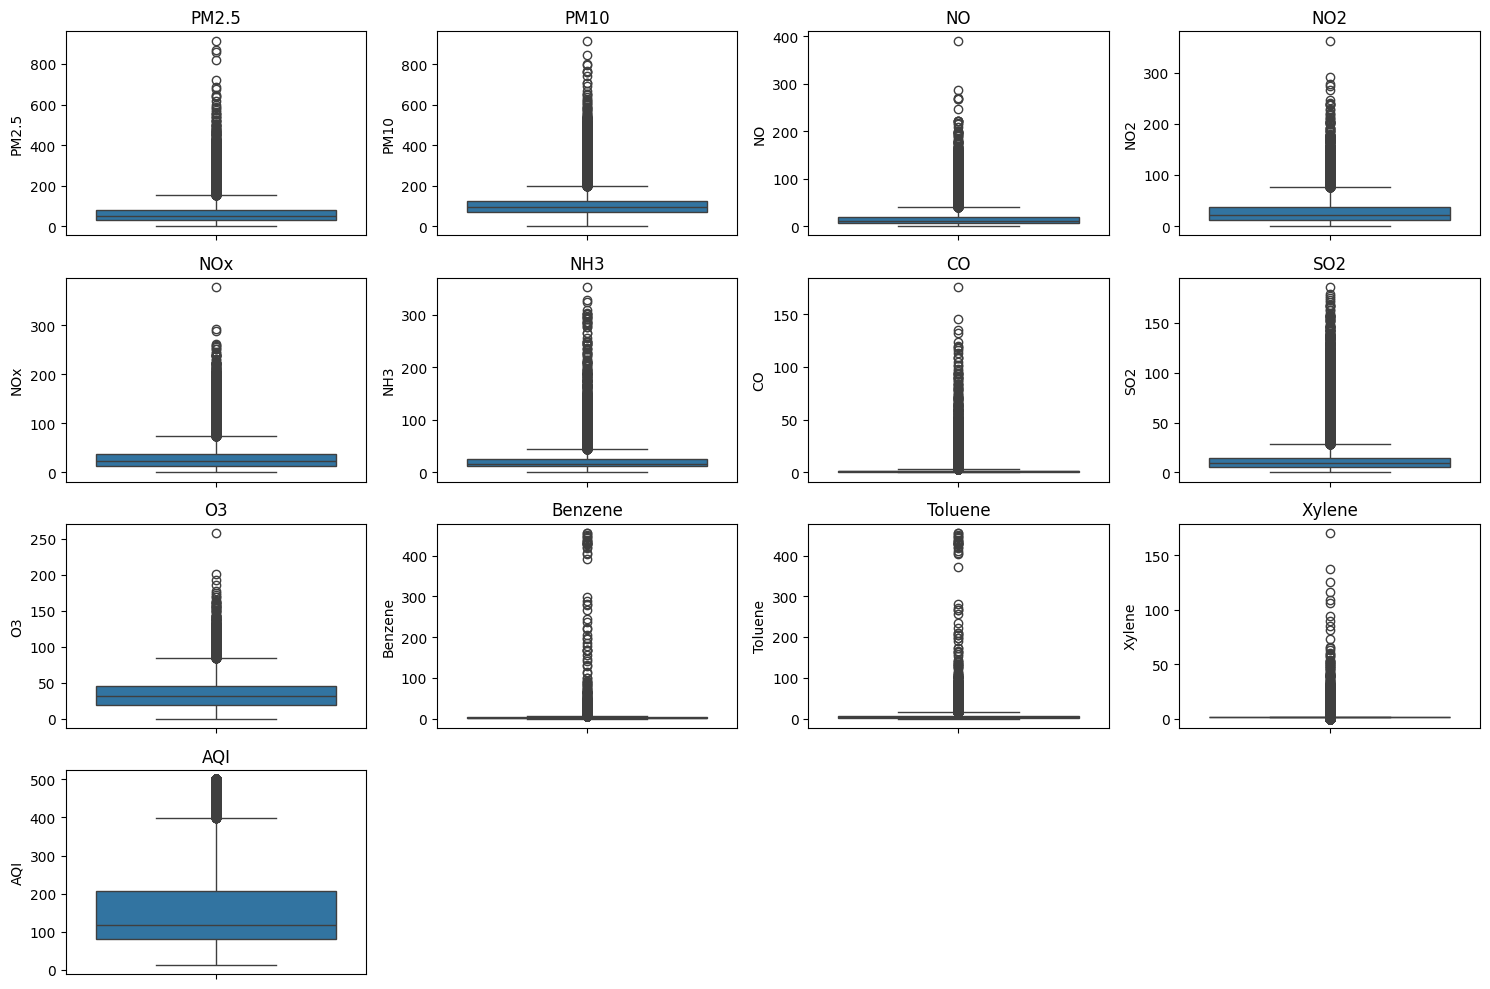

In [20]:
# boxplot visualisation
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))

for i, col in enumerate(pollutants):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [21]:
# detect outliers using IQR Method
outlier_summary = {}

for col in pollutants:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

# Convert to DataFrame
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Column','Outlier_Count'])
outlier_df.sort_values(by='Outlier_Count', ascending=False)

,Column,Outlier_Count
11,Xylene,9465
10,Toluene,3185
7,SO2,2481
1,PM10,2453
2,NO,2411
6,CO,2327
5,NH3,2144
0,PM2.5,2011
9,Benzene,1952
4,NOx,1945


In [22]:
# now we check descriptive stats for all columns
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285,66.966637,112.102860,17.502312,28.870163,31.645675,21.865639,2.319923,14.237723,34.793934,3.150167,8.130589,2.247154,160.920684
min,2015-01-01 00:00:00,0.040000,0.030000,0.030000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,2017-08-16 00:00:00,29.560000,71.780000,5.720000,12.090000,14.030000,11.280000,0.590000,5.790000,19.640000,0.340000,1.580000,1.420000,81.000000
50%,2018-11-05 00:00:00,48.785000,96.180000,9.910000,22.100000,23.680000,16.310000,0.930000,9.220000,31.250000,1.290000,3.575000,1.420000,118.000000
75%,2019-10-11 00:00:00,79.507500,122.957500,19.710000,37.910000,38.170000,24.710000,1.460000,14.890000,45.397500,2.850000,7.380000,1.420000,208.000000
max,2020-07-01 00:00:00,914.940000,917.080000,390.680000,362.210000,378.240000,352.890000,175.810000,186.080000,257.730000,455.030000,454.850000,170.370000,500.000000
std,NaN,62.283431,76.325808,22.266346,24.447523,29.629575,22.460343,7.014082,17.233456,21.378711,14.870955,18.443104,4.302180,113.180357


In [23]:
# Xylene has very low variability (75% values same), so we remove it
if 'Xylene' in df.columns:
    df = df.drop('Xylene', axis=1)

In [24]:
# Log transform Helps reduce skewness caused by extreme pollution values
cols_to_transform = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']
for col in cols_to_transform:
    if col in df.columns:
        df[col] = np.log1p(df[col])

In [25]:
df.describe()

,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI
count,24850,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000,24850.000000
mean,2018-07-24 18:51:25.714285,3.918959,4.544367,2.477266,3.109017,3.129346,2.851119,0.792507,2.397614,3.382119,0.925736,1.601464,160.920684
min,2015-01-01 00:00:00,0.039221,0.029559,0.029559,0.009950,0.000000,0.009950,0.000000,0.009950,0.009950,0.000000,0.000000,13.000000
25%,2017-08-16 00:00:00,3.419692,4.287441,1.905088,2.571849,2.710048,2.507972,0.463734,1.915451,3.027231,0.292670,0.947789,81.000000
50%,2018-11-05 00:00:00,3.907714,4.576565,2.389680,3.139833,3.205993,2.851284,0.657520,2.324347,3.473518,0.828552,1.520607,118.000000
75%,2019-10-11 00:00:00,4.388350,4.819939,3.030617,3.661251,3.667911,3.246880,0.900161,2.765690,3.837246,1.348073,2.125848,208.000000
max,2020-07-01 00:00:00,6.819951,6.822285,5.970445,5.894981,5.938169,5.868986,5.175076,5.231536,5.555785,6.122559,6.122164,500.000000
std,NaN,0.766185,0.625421,0.902400,0.788678,0.916251,0.734236,0.641562,0.739503,0.685281,0.771671,1.005246,113.180357


### Outlier Handling:

Outliers were analyzed using descriptive statistics and boxplots. Most pollutant variables showed high maximum values compared to their quartiles, indicating right-skewed distributions due to real-world pollution spikes.
Instead of removing outliers, they were retained because they represent genuine environmental conditions and are important for accurate AQI prediction.
To reduce skewness and stabilize variance, log transformation (log1p) was applied to pollutant variables.
The Xylene feature was removed as it showed very low variance (75% of values were identical) along with extreme spikes, indicating low predictive value and unstable behavior.

### Feature engineering

In [26]:
# extracted time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday 

In [27]:
# introduced seasonality and encoded it
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
df = pd.get_dummies(df, columns=['Season'], drop_first=True)

In [28]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Toluene,AQI,AQI_Bucket,Year,Month,Day,Weekday,Season_Monsoon,Season_Summer,Season_Winter
28,Ahmedabad,2015-01-29,4.432363,4.576565,2.070653,3.391484,3.547316,2.851284,2.070653,3.922369,...,0.000000,209.0,Poor,2015,1,29,3,False,False,True
29,Ahmedabad,2015-01-30,4.392472,4.576565,2.698000,3.390473,3.739573,2.851284,2.698000,3.901771,...,0.000000,328.0,Very Poor,2015,1,30,4,False,False,True
30,Ahmedabad,2015-01-31,4.559336,4.576565,3.234355,3.516310,3.981736,2.851284,3.234355,4.225227,...,0.009950,500.0,Severe,2015,1,31,5,False,False,True
31,Ahmedabad,2015-02-01,4.919908,4.576565,3.795040,3.763059,4.449335,2.851284,3.795040,4.333755,...,0.039221,500.0,Severe,2015,2,1,6,False,False,True
32,Ahmedabad,2015-02-02,5.189228,4.576565,4.017464,3.592093,4.301359,2.851284,4.017464,4.026066,...,0.058269,500.0,Severe,2015,2,2,0,False,False,True


### EDA (Exploratory Data Analysis)

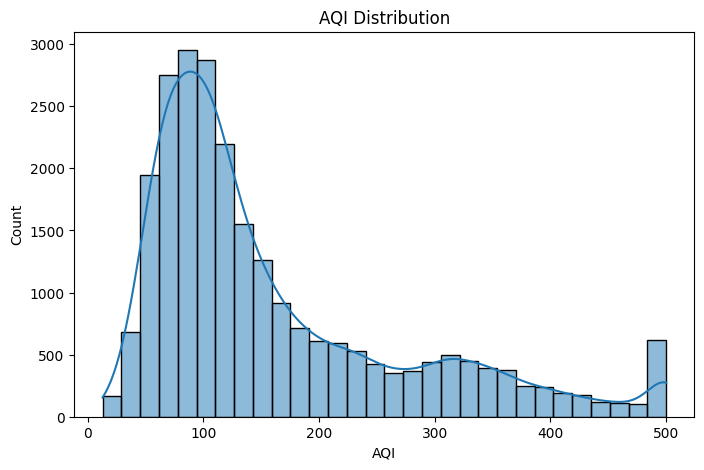

In [29]:
# first we identify common AQI ranges
plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=30, kde=True)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Count")
plt.show()

AQI values are right-skewed, with most observations in the moderate range (50–200) and some extreme pollution events reaching up to 500.

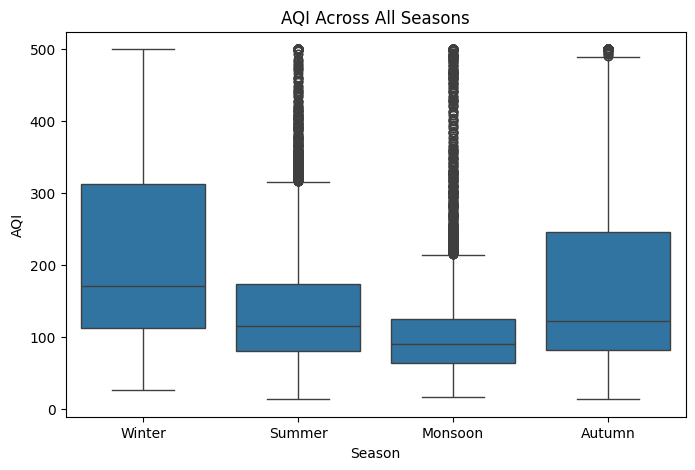

In [30]:
# AQI vs season
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8]:
        return 'Monsoon'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='AQI', data=df)
plt.title("AQI Across All Seasons")
plt.show()

AQI is highest in winter and lowest during monsoon. This indicates that weather conditions such as low temperature and rainfall significantly impact pollution levels.

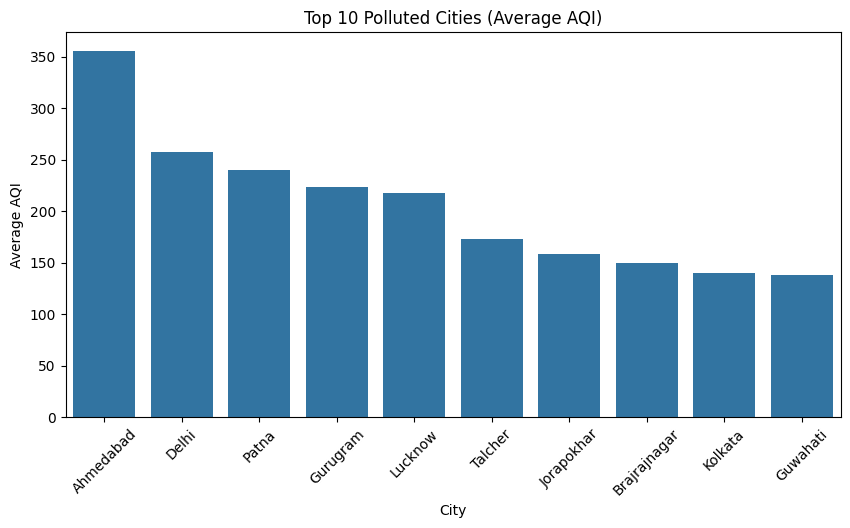

In [31]:
# top polluted cities
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=city_aqi.index, y=city_aqi.values)
plt.title("Top 10 Polluted Cities (Average AQI)")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.show()

Cities like Ahmedabad, Delhi, and Patna show consistently high AQI, identifying them as major pollution hotspots.

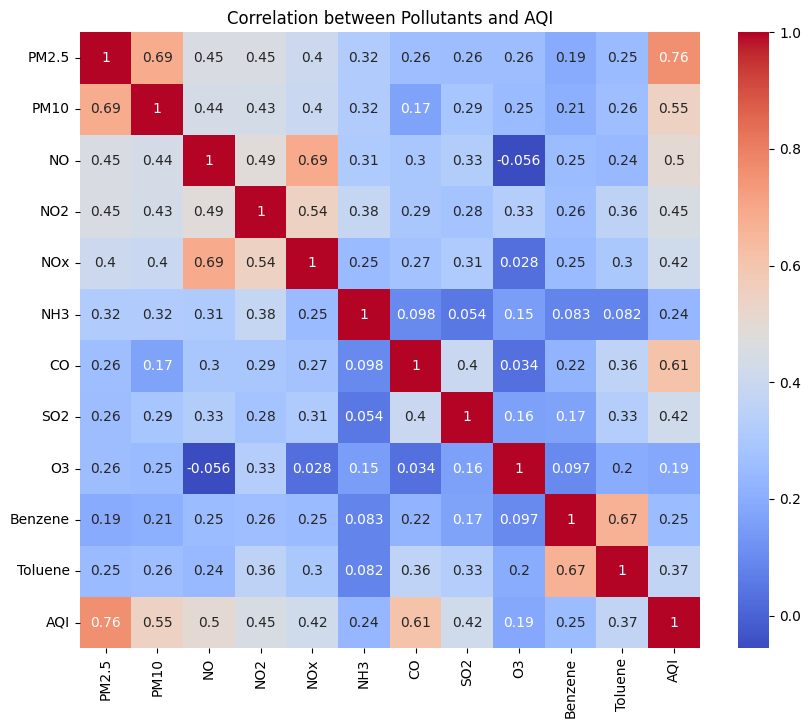

In [32]:
# pollutants vs AQI
plt.figure(figsize=(10,8))
sns.heatmap(df[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','AQI']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between Pollutants and AQI")
plt.show()

Correlation analysis shows that PM2.5 has the strongest relationship with AQI, followed by PM10 and CO, highlighting particulate matter as the key driver of air pollution.

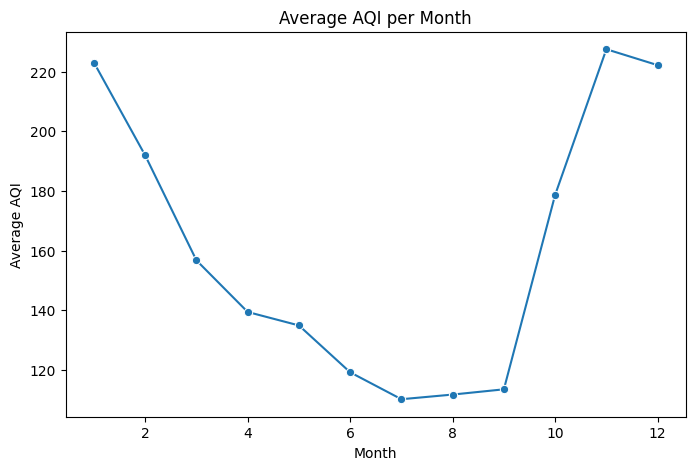

In [33]:
# Average AQI per month
monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_aqi.index, y=monthly_aqi.values, marker='o')
plt.title("Average AQI per Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

AQI peaks during November–January and is lowest during July–August, confirming strong seasonal variation in air quality.

### Pollutant Impact Analysis

In [34]:
# using Feature Importance
corr = df[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','AQI']].corr()
corr_target = corr['AQI'].sort_values(ascending=False)
print(corr_target)

AQI        1.000000
PM2.5      0.761366
CO         0.611000
PM10       0.547398
NO         0.501686
NO2        0.449113
NOx        0.421980
SO2        0.420583
Toluene    0.371958
Benzene    0.251898
NH3        0.236224
O3         0.185770
Name: AQI, dtype: float64


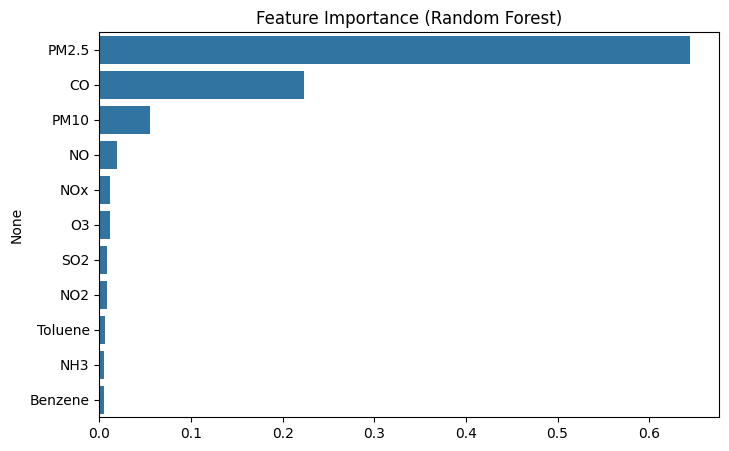

In [35]:
from sklearn.ensemble import RandomForestRegressor
# Features and target
X = df[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene']]
y = df['AQI']
# Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
# Feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

Correlation and feature importance analysis were performed to identify key drivers of AQI.
PM2.5 was found to have the strongest influence on AQI, followed by PM10 and CO, indicating that particulate matter is the primary contributor to air pollution.
Other gases such as NO2 and SO2 showed moderate impact, while pollutants like Benzene and Toluene had relatively lower influence.
Random Forest feature importance confirmed these findings, reinforcing the dominance of particulate pollutants in determining AQI levels.

### AQI Prediction

In [36]:
features = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene',
            'Month','Day','Weekday']  # include time features

X = df[features]
y = df['AQI']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [39]:
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} -> MAE: {mae:.2f}, R2: {r2:.2f}")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")

Linear Regression -> MAE: 40.18, R2: 0.78
Random Forest -> MAE: 18.23, R2: 0.93
Gradient Boosting -> MAE: 19.52, R2: 0.93


Tree-based models significantly outperformed Linear Regression, indicating that AQI depends on non-linear interactions between pollutants. Random Forest achieved the lowest MAE and highest R², making it the most suitable model for AQI prediction.

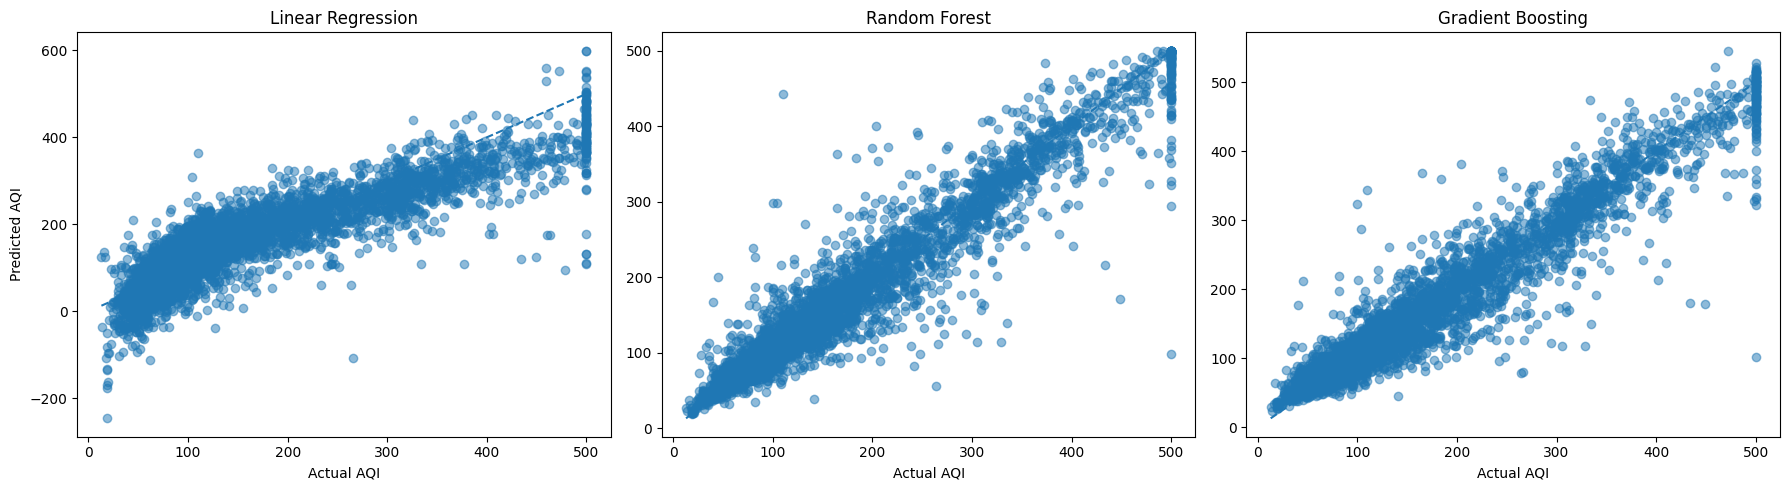

In [40]:
plt.figure(figsize=(18,5))

# Linear Regression
plt.subplot(1,3,1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.title("Linear Regression")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

# Random Forest
plt.subplot(1,3,2)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.title("Random Forest")
plt.xlabel("Actual AQI")

# Gradient Boosting
plt.subplot(1,3,3)
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.title("Gradient Boosting")
plt.xlabel("Actual AQI")

plt.tight_layout()
plt.show()

### AQI Forecsting

In [41]:
df.info()

<class 'pandas.DataFrame'>
Index: 24850 entries, 28 to 29530
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   City            24850 non-null  str           
 1   Date            24850 non-null  datetime64[us]
 2   PM2.5           24850 non-null  float64       
 3   PM10            24850 non-null  float64       
 4   NO              24850 non-null  float64       
 5   NO2             24850 non-null  float64       
 6   NOx             24850 non-null  float64       
 7   NH3             24850 non-null  float64       
 8   CO              24850 non-null  float64       
 9   SO2             24850 non-null  float64       
 10  O3              24850 non-null  float64       
 11  Benzene         24850 non-null  float64       
 12  Toluene         24850 non-null  float64       
 13  AQI             24850 non-null  float64       
 14  AQI_Bucket      24850 non-null  category      
 15  Year            2

In [42]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
cities = ['Delhi', 'Ahmedabad', 'Patna']
df = df[df['City'].isin(cities)]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['City','Date'])
df['AQI'] = df.groupby('City')['AQI'].ffill()  # Fill missing AQI

df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_df = df.groupby(['City','YearMonth'])['AQI'].mean().reset_index()
monthly_df['YearMonth'] = monthly_df['YearMonth'].dt.to_timestamp()

ModuleNotFoundError: No module named 'prophet'

In [ ]:
results = []

for city in cities:
    temp = monthly_df[monthly_df['City']==city].copy()
    split = -6  # last 6 months test
    train = temp.iloc[:split]
    test = temp.iloc[split:]
    
    
    # Baseline 1: Mean
    mean_pred = [train['AQI'].mean()] * len(test)
    results.append({'City':city, 'Model':'Mean', 'MAE': mean_absolute_error(test['AQI'], mean_pred)})
    
    # Baseline 2: Naive (last month)
    naive_pred = test['AQI'].shift(1)
    naive_pred.iloc[0] = train['AQI'].iloc[-1]
    results.append({'City':city, 'Model':'Naive', 'MAE': mean_absolute_error(test['AQI'], naive_pred)})
    
    # Baseline 3: Seasonal Naive (same month last year)
    seasonal_pred = []
    for i in range(len(test)):
        # find same month last year
        month = test['YearMonth'].iloc[i].month
        year = test['YearMonth'].iloc[i].year - 1
        match = train[(train['YearMonth'].dt.month==month) & (train['YearMonth'].dt.year==year)]
        if len(match)==0:
            seasonal_pred.append(train['AQI'].iloc[-1])  # fallback to last train value
        else:
            seasonal_pred.append(match['AQI'].values[0])
    results.append({'City':city, 'Model':'Seasonal Naive', 'MAE': mean_absolute_error(test['AQI'], seasonal_pred)})
    
    # ---------------------
    # Prophet Forecast
    prophet_train = train.rename(columns={'YearMonth':'ds','AQI':'y'})
    model = Prophet(yearly_seasonality=True, daily_seasonality=False, weekly_seasonality=False)
    model.fit(prophet_train)
    
    future = model.make_future_dataframe(periods=len(test), freq='M')
    forecast = model.predict(future)
    
    prophet_pred = forecast['yhat'][-len(test):].values
    results.append({'City':city, 'Model':'Prophet', 'MAE': mean_absolute_error(test['AQI'], prophet_pred)})
    
    # Plot forecast
    model.plot(forecast)
    plt.title(f"Prophet Forecast - {city}")
    plt.show()


In [ ]:
results_df = pd.DataFrame(results)
print("MAE Comparison:")
print(results_df.pivot(index='City', columns='Model', values='MAE'))

Naive baseline is strong: AQI exhibits high month-to-month autocorrelation. Predicting the previous month performs well for all cities.
Seasonal Naive can underperform: Irregular spikes or missing data in prior years reduce accuracy (e.g., Ahmedabad).
Prophet effectiveness:
Works well for Delhi and Patna (consistent seasonal trends).
Struggles for Ahmedabad due to extreme AQI spikes and irregular patterns.
Mean model is the weakest: AQI is highly variable and cannot be predicted by the average alone.

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

# Loop over cities to perform time-series cross-validation
cv_results = []

for city in cities:
    temp = monthly_df[monthly_df['City']==city][['YearMonth','AQI']].rename(columns={'YearMonth':'ds','AQI':'y'})
    
    # Fit Prophet on full data
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(temp)
    
    # Cross-validation settings
    # initial: first 2 years (~24 months) as training
    # period: roll forward every month
    # horizon: forecast 6 months ahead
    df_cv = cross_validation(model, initial='730 days', period='30 days', horizon='180 days', parallel="processes")
    
    # Compute performance metrics (MAE, RMSE, MAPE)
    df_p = performance_metrics(df_cv)
    mean_mae = df_p['mae'].mean()
    
    cv_results.append({'City':city, 'Model':'Prophet_CV', 'MAE': mean_mae})

# Convert to DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Combine with previous MAE results
all_mae = pd.concat([results_df, cv_results_df], ignore_index=True)
print("MAE Comparison with Time-Series CV for Prophet:")
print(all_mae.pivot(index='City', columns='Model', values='MAE'))

In [ ]:
# Top 3 regressors
top_regressors = ['PM2.5','PM10','CO']

# Compute monthly averages for regressors
monthly_regressors = df.groupby(['City','YearMonth'])[top_regressors].mean().reset_index()
monthly_regressors['YearMonth'] = monthly_regressors['YearMonth'].dt.to_timestamp()

# Merge with AQI monthly data
monthly_df_full = monthly_df.merge(monthly_regressors, on=['City','YearMonth'], how='left')

# Prophet with regressors
regressor_results = []

for city in cities:
    temp = monthly_df_full[monthly_df_full['City']==city].copy()
    split = -6  # last 6 months test
    train = temp.iloc[:split]
    test = temp.iloc[split:]
    
    prophet_train = train.rename(columns={'YearMonth':'ds','AQI':'y'})
    
    # Add top regressors
    for r in top_regressors:
        prophet_train[r] = train[r].values
    
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for r in top_regressors:
        model.add_regressor(r)
    
    model.fit(prophet_train)
    
    # Future dataframe including regressors
    future = model.make_future_dataframe(periods=len(test), freq='M')
    for r in top_regressors:
        future[r] = temp[r].values
    
    forecast = model.predict(future)
    prophet_reg_pred = forecast['yhat'][-len(test):].values
    
    regressor_results.append({
        'City': city,
        'Model': 'Prophet_with_Top3_Regressors',
        'MAE': mean_absolute_error(test['AQI'], prophet_reg_pred)
    })
    
    model.plot(forecast)
    plt.title(f"Prophet Forecast with Top 3 Regressors - {city}")
    plt.show()

# Combine results
regressor_results_df = pd.DataFrame(regressor_results)
all_mae_with_regressors = pd.concat([all_mae, regressor_results_df], ignore_index=True)
print("MAE Comparison including Prophet with Top 3 Regressors:")
print(all_mae_with_regressors.pivot(index='City', columns='Model', values='MAE'))

In [ ]:
# Cities to forecast
cities = ['Delhi', 'Ahmedabad', 'Patna']

# Top 3 regressors identified from feature importance
top_regressors = ['PM2.5','PM10','CO']

# Prepare results list
cv_regressor_results = []

for city in cities:
    # Filter city data
    temp = df[df['City']==city].copy()
    temp = temp.sort_values('Date')
    
    # Monthly aggregation
    temp['YearMonth'] = temp['Date'].dt.to_period('M')
    monthly_temp = temp.groupby('YearMonth').agg(
        AQI=('AQI','mean'),
        **{r: (r,'mean') for r in top_regressors}  # add top regressors
    ).reset_index()
    monthly_temp['YearMonth'] = monthly_temp['YearMonth'].dt.to_timestamp()
    
    # Rename for Prophet
    prophet_train = monthly_temp.rename(columns={'YearMonth':'ds','AQI':'y'})
    
    # Initialize Prophet with regressors
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    
    # Add top 3 regressors
    for r in top_regressors:
        model.add_regressor(r)
    
    # Fit model
    model.fit(prophet_train)
    
    # Cross-validation settings
    # initial = first 2 years (~730 days)
    # period = roll forward every month (~30 days)
    # horizon = forecast 6 months (~180 days)
    df_cv = cross_validation(model, initial='730 days', period='30 days', horizon='180 days', parallel="processes")
    
    # Performance metrics
    df_p = performance_metrics(df_cv)
    mean_mae = df_p['mae'].mean()
    
    cv_regressor_results.append({
        'City': city,
        'Model': 'Prophet_with_Top3_Regressors_CV',
        'MAE': mean_mae
    })

# Convert to DataFrame
cv_regressor_df = pd.DataFrame(cv_regressor_results)

# Combine with previous MAE results if needed
all_mae_final = pd.concat([all_mae, cv_regressor_df], ignore_index=True)
print("MAE Comparison including Prophet with Top 3 Regressors + CV:")
print(all_mae_final.pivot(index='City', columns='Model', values='MAE'))